<a href="https://colab.research.google.com/github/WayneNganju/D-10-Lab-on-Regression/blob/main/D10_farm_income_regression_~_Lab_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Team Introduction

**D10: Farm Annual Income Regression**

**Course:** Business Intelligence   
**Team:** D10  
**Team size:** 5  
**Dataset:** `farm_annual_income.csv`  
**Target variable:** `annual_farm_income_kes`

## Business Problem

This project develops regression models to predict a farm's annual income in Kenyan shillings (KES) from observable farm, production, location, financing, and operational characteristics.

The model is intended for forecasting and decision support. It identifies patterns associated with annual farm income, but it does not prove that any predictor causes income to change.

## 1. Environment Setup and Imports

The analysis uses a fixed random seed so that the train/test split and all stochastic modeling steps can be reproduced.

In [ ]:
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "annual_farm_income_kes"

np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print(f"Python version: {sys.version.split()[0]}")
print(f"Target variable: {TARGET}")

Python version: 3.13.15
Target variable: annual_farm_income_kes


## 2. Data Loading

The Group D dataset is loaded directly from the course repository. This avoids depending on temporary files in a Colab session.

In [ ]:
DATA_URL = (
    "https://raw.githubusercontent.com/course-files/RegressionAndClassification/main/data/farm_annual_income.csv"
)

farm_data = pd.read_csv(DATA_URL, encoding="utf-8")

if TARGET not in farm_data.columns:
    raise KeyError(
        f"Expected target '{TARGET}' was not found. Available columns: "
        f"{farm_data.columns.tolist()}"
    )

print(f"Dataset shape: {farm_data.shape[0]:,} rows and {farm_data.shape[1]:,} columns")
display(farm_data.head())

Dataset shape: 850 rows and 16 columns


,farm_id,crop_type,county,irrigation_type,cooperative_member,farm_size_acres,years_farming_experience,num_workers_employed,rainfall_mm,soil_quality_score,market_distance_km,machinery_value_kes,fertilizer_spend_kes,pesticide_spend_kes,irrigation_maintenance_cost_kes,annual_farm_income_kes
0,1,Tea,Uasin Gishu,Drip,No,7.26,10.0,1,1345.0,NaN,5.7,31304.0,22569.0,11598.0,20609.323557,240514.0
1,2,Tea,Nakuru,Drip,No,15.73,39.8,4,739.0,38.000299,11.3,156636.0,52716.0,13887.0,2849.905605,562457.0
2,3,Tea,Uasin Gishu,NaN,No,7.75,3.3,2,1101.0,57.136048,29.3,15966.0,28291.0,10697.0,NaN,176021.0
3,4,Coffee,Nakuru,NaN,No,3.90,30.6,1,831.0,73.593459,14.1,29920.0,16108.0,5383.0,NaN,283876.0
4,5,Tea,Kericho,Manual,No,10.49,9.3,1,967.0,54.498549,6.0,115136.0,28664.0,4486.0,3207.355224,242651.0


In [ ]:
farm_data.info()

print("\nColumn names:")
print(farm_data.columns.tolist())

print(f"\nSummary of {TARGET}:")
display(farm_data[TARGET].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   farm_id                          850 non-null    int64  
 1   crop_type                        850 non-null    object 
 2   county                           850 non-null    object 
 3   irrigation_type                  547 non-null    object 
 4   cooperative_member               850 non-null    object 
 5   farm_size_acres                  850 non-null    float64
 6   years_farming_experience         850 non-null    float64
 7   num_workers_employed             850 non-null    int64  
 8   rainfall_mm                      850 non-null    float64
 9   soil_quality_score               807 non-null    float64
 10  market_distance_km               850 non-null    float64
 11  machinery_value_kes              850 non-null    float64
 12  fertilizer_spend_kes  

,annual_farm_income_kes
count,8.500000e+02
mean,2.686471e+05
std,1.608326e+05
min,5.653400e+04
25%,1.683308e+05
50%,2.237460e+05
75%,3.279118e+05
max,2.060104e+06


### Initial Data Understanding

This dataset has 16 columns and 850 observations. The target variable is `annual_farm_income_kes`, which gives the annual income of each farm in Kenyan shillings (KES).

The data contains an ID column called `farm_id`, categorical columns such as `crop_type`, `county`, `irrigation_type`, and `cooperative_member`, and numeric columns containing operational, environmental, and financial data. Some examples of numeric predictors are the number of workers on the farm, farm size, farming experience, irrigation maintenance cost, fertilizer expenditure, pesticide expenditure, market distance, soil quality, and the value of machinery.

As seen in the preview, some variables, such as `soil_quality_score`, `irrigation_type`, and `irrigation_maintenance_cost_kes`, have missing values. The reasons for this missing data should be studied during exploratory data analysis before selecting a suitable data preprocessing method. The `farm_id` column is not a meaningful farm characteristic and will therefore not be used for predictive modeling after the train/test split.

## 3. Exploratory Data Analysis

Exploratory data analysis is carried out to understand the variables in the dataset before building any regression model. In this section, we examine the types of variables, missing values, distributions, potential outliers, and the relationships between numeric predictors and annual farm income.

The original `farm_data` DataFrame is used in this section. No variables are removed, transformed, encoded, imputed, or used to train a model at this stage.

In [ ]:
numeric_cols = farm_data.select_dtypes(include=np.number).columns.tolist()

categorical_cols = farm_data.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

missingness = (
    farm_data.isna()
    .sum()
    .to_frame("missing_count")
    .assign(
        missing_pct=lambda frame: (
            frame["missing_count"] / len(farm_data) * 100
        )
    )
    .sort_values("missing_pct", ascending=False)
)

display(missingness)

Numeric columns:
['farm_id', 'farm_size_acres', 'years_farming_experience', 'num_workers_employed', 'rainfall_mm', 'soil_quality_score', 'market_distance_km', 'machinery_value_kes', 'fertilizer_spend_kes', 'pesticide_spend_kes', 'irrigation_maintenance_cost_kes', 'annual_farm_income_kes']

Categorical columns:
['crop_type', 'county', 'irrigation_type', 'cooperative_member']


,missing_count,missing_pct
irrigation_type,303,35.647059
irrigation_maintenance_cost_kes,303,35.647059
soil_quality_score,43,5.058824
farm_id,0,0.000000
cooperative_member,0,0.000000
farm_size_acres,0,0.000000
crop_type,0,0.000000
county,0,0.000000
num_workers_employed,0,0.000000
years_farming_experience,0,0.000000


### Variable Types and Missing Values

The dataset has 12 numeric columns and 4 categorical columns. One numeric column, `farm_id`, is an identifier and will not be used as a predictive feature after the train/test split. The remaining numeric columns include farm size, farming experience, number of workers, rainfall, soil quality, market distance, machinery value, farm expenditures, and annual farm income. The categorical columns describe the crop grown, county, irrigation type, and cooperative membership.

There are missing values in three variables. Both `irrigation_type` and `irrigation_maintenance_cost_kes` have 303 missing values, representing 35.65% of the dataset. Since these variables have the same number of missing values, their missingness may be related. `soil_quality_score` has 43 missing values, representing 5.06% of the dataset.

At this stage, no missing values are imputed. The relationship between the irrigation variables will first be examined to determine whether their missingness is structural or random. Any imputation method will later be fitted using training data only.

In [ ]:
irrigation_missingness_check = pd.crosstab(
    farm_data["irrigation_type"].isna(),
    farm_data["irrigation_maintenance_cost_kes"].isna(),
    margins=True
)

irrigation_missingness_check.index = [
    "Irrigation type observed",
    "Irrigation type missing",
    "Total"
]

irrigation_missingness_check.columns = [
    "Maintenance cost observed",
    "Maintenance cost missing",
    "Total"
]

display(irrigation_missingness_check)

print("Irrigation type categories where maintenance cost is observed:")
display(
    farm_data.loc[
        farm_data["irrigation_maintenance_cost_kes"].notna(),
        "irrigation_type"
    ].value_counts(dropna=False)
)

,Maintenance cost observed,Maintenance cost missing,Total
Irrigation type observed,547,0,547
Irrigation type missing,0,303,303
Total,547,303,850


Irrigation type categories where maintenance cost is observed:


,count
irrigation_type,
Manual,225
Drip,198
Automated,124


### **Irrigation Missingness Check**

The missing values in `irrigation_type` and `irrigation_maintenance_cost_kes` occur together for the same 303 farms. All 547 farms with an observed irrigation type also have an observed irrigation maintenance cost. Similarly, every farm with a missing irrigation type has a missing irrigation maintenance cost.

This pattern suggests that the missing values are not random. It is likely that these farms do not use a recorded irrigation method, and therefore do not have an irrigation maintenance cost. This is likely to be structural missingness because the maintenance cost may not apply to farms without irrigation.

Among farms with observed irrigation information, 225 use manual irrigation, 198 use drip irrigation, and 124 use automated irrigation. During preprocessing, the irrigation-related missing values should be handled carefully so that the model can retain information about farms with no recorded irrigation.

### Distribution of Numeric Variables

The numeric variables are examined using measures of central tendency and distribution. These include the minimum value, lower quartile, median, upper quartile, maximum value, mean, standard deviation, skewness, and kurtosis.

Skewness helps to show whether a variable is distributed symmetrically or has a long tail on one side. Kurtosis helps to show whether a variable has unusually heavy tails or extreme values. These results will help to identify variables that may require transformation or further investigation.

In [ ]:
numeric_cols_without_id = [
    column for column in numeric_cols
    if column != "farm_id"
]

q1 = farm_data[numeric_cols_without_id].quantile(0.25)
q2 = farm_data[numeric_cols_without_id].quantile(0.50)
q3 = farm_data[numeric_cols_without_id].quantile(0.75)

distribution_summary = pd.DataFrame(
    {
        "minimum": farm_data[numeric_cols_without_id].min(),
        "q1_25%": q1,
        "median_q2_50%": q2,
        "q3_75%": q3,
        "maximum": farm_data[numeric_cols_without_id].max(),
        "mean": farm_data[numeric_cols_without_id].mean(),
        "standard_deviation": farm_data[numeric_cols_without_id].std(),
        "skewness": farm_data[numeric_cols_without_id].skew(),
        "kurtosis": farm_data[numeric_cols_without_id].kurt(),
    }
)

display(distribution_summary.round(2))

,minimum,q1_25%,median_q2_50%,q3_75%,maximum,mean,standard_deviation,skewness,kurtosis
farm_size_acres,0.5,3.90,6.34,10.09,31.44,7.68,5.15,1.19,1.40
years_farming_experience,0.5,6.72,11.40,17.70,45.00,13.37,8.86,1.25,1.56
num_workers_employed,0.0,1.00,2.00,3.00,9.00,2.03,1.68,0.76,0.26
rainfall_mm,250.0,800.00,951.00,1091.75,1566.00,946.02,218.53,0.02,-0.08
soil_quality_score,5.0,49.73,61.61,73.89,100.00,61.63,17.18,-0.16,-0.12
market_distance_km,1.0,8.10,13.65,22.20,68.50,16.39,11.50,1.27,1.81
machinery_value_kes,0.0,29763.50,56409.50,95019.00,350170.00,69103.23,55154.40,1.31,1.92
fertilizer_spend_kes,1104.0,11143.00,19577.00,33529.00,133274.00,24391.90,18199.56,1.58,3.73
pesticide_spend_kes,199.0,4718.25,8587.50,13805.25,50169.00,10560.84,8272.50,1.63,3.43
irrigation_maintenance_cost_kes,500.0,4057.64,7532.92,12234.66,36866.42,8994.86,6353.07,1.30,2.00


The target variable, `annual_farm_income_kes`, has a mean of 268,647.10 KES and a median of 223,746.00 KES. Since the mean is higher than the median, this suggests that some farms have relatively high annual incomes which increase the average income.

The annual farm income ranges from 56,534.00 KES to 2,060,104.00 KES. Its skewness is 3.38, which shows that the target is strongly skewed to the right. Its kurtosis is 23.58, which suggests that there are extreme income values in the upper end of the distribution.

Most of the expenditure and machinery variables are also positively skewed. In particular, `fertilizer_spend_kes` and `pesticide_spend_kes` have skewness values above 1.5 and relatively high kurtosis values. This indicates that a small number of farms have much higher expenditure levels than most farms.

Since `annual_farm_income_kes` is strictly positive and strongly right-skewed, a `log1p` transformation will later be considered for the target variable. This transformation can reduce the influence of very high income values during model training.

### Distribution of Annual Farm Income

The distribution of the target variable is examined using a histogram and a boxplot. The histogram shows the general shape of annual farm income, while the boxplot helps to identify possible extreme income values.

This is important because regression models can be affected when the target variable is strongly skewed or contains extreme observations.

Target skewness: 3.379
Target kurtosis: 23.576
Target minimum: 56,534.00 KES
Target maximum: 2,060,104.00 KES


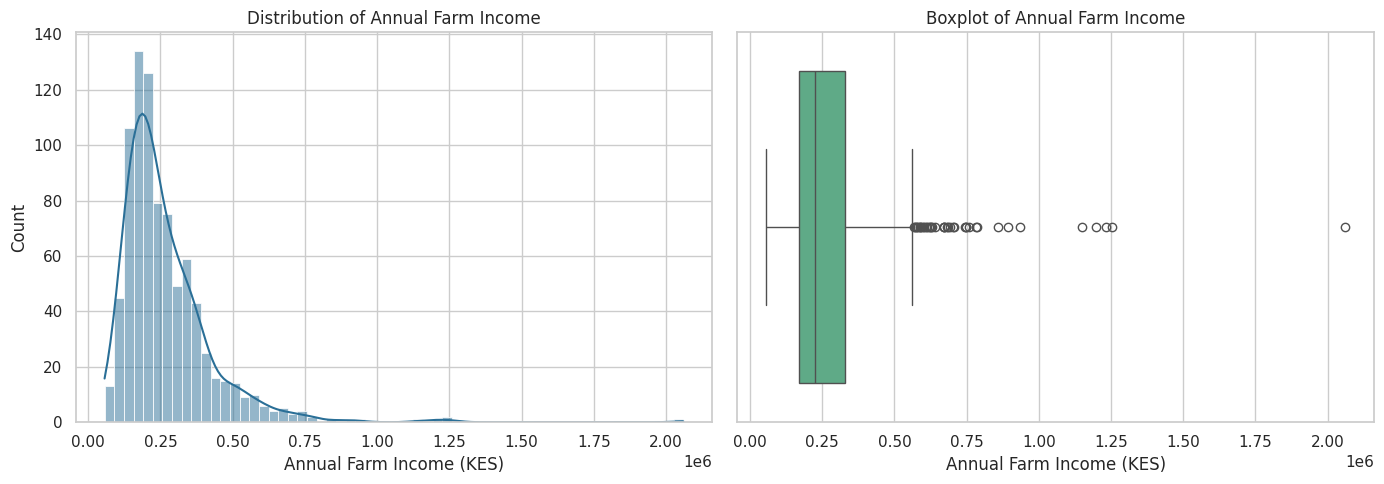

In [ ]:
target_skewness = farm_data[TARGET].skew()
target_kurtosis = farm_data[TARGET].kurt()

print(f"Target skewness: {target_skewness:.3f}")
print(f"Target kurtosis: {target_kurtosis:.3f}")
print(f"Target minimum: {farm_data[TARGET].min():,.2f} KES")
print(f"Target maximum: {farm_data[TARGET].max():,.2f} KES")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(farm_data[TARGET], kde=True, ax=axes[0], color="#2A6F97")
axes[0].set_title("Distribution of Annual Farm Income")
axes[0].set_xlabel("Annual Farm Income (KES)")

sns.boxplot(x=farm_data[TARGET], ax=axes[1], color="#52B788")
axes[1].set_title("Boxplot of Annual Farm Income")
axes[1].set_xlabel("Annual Farm Income (KES)")

plt.tight_layout()
plt.show()

The annual farm income ranges from 56,534.00 KES to 2,060,104.00 KES. The target has a skewness of 3.38 and a kurtosis of 23.58. This shows that annual farm income is strongly skewed to the right and has some extreme high-income farms.

The histogram shows that most farms have lower to moderate annual incomes, while a small number of farms have much higher incomes. The boxplot also shows potential high-income outliers.

Since `annual_farm_income_kes` is strictly positive and strongly right-skewed, a `log1p` transformation will later be considered before modeling. This transformation can reduce the effect of very high farm incomes and make the target distribution more suitable for regression modeling.

### Potential Outliers

The interquartile range (IQR) method is used to identify possible outliers in the numeric variables. A value is considered a potential outlier when it is below the lower fence or above the upper fence.

The lower fence is calculated as:

$Q1 - 1.5 \times IQR$

The upper fence is calculated as:

$Q3 + 1.5 \times IQR$

Potential outliers will be investigated, but they will not be automatically removed because unusually large farms, high expenditure values, or high farm incomes may be valid observations.

In [ ]:
q1 = farm_data[numeric_cols_without_id].quantile(0.25)
q3 = farm_data[numeric_cols_without_id].quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outlier_mask = (
    (farm_data[numeric_cols_without_id] < lower_fence)
    | (farm_data[numeric_cols_without_id] > upper_fence)
)

outlier_summary = pd.DataFrame(
    {
        "potential_outlier_count": outlier_mask.sum(),
        "potential_outlier_pct": (
            outlier_mask.sum() / len(farm_data) * 100
        ),
    }
).sort_values("potential_outlier_count", ascending=False)

display(outlier_summary.round(2))

,potential_outlier_count,potential_outlier_pct
annual_farm_income_kes,39,4.59
pesticide_spend_kes,37,4.35
farm_size_acres,35,4.12
machinery_value_kes,34,4.00
years_farming_experience,31,3.65
market_distance_km,30,3.53
fertilizer_spend_kes,28,3.29
irrigation_maintenance_cost_kes,16,1.88
num_workers_employed,10,1.18
rainfall_mm,5,0.59


### Relationships Between Numeric Variables and Annual Farm Income

Pearson correlation is used to measure linear relationships between numeric variables and annual farm income. Spearman correlation is also used because it can identify monotonic relationships that may not be perfectly linear.

Comparing the Pearson and Spearman correlation values helps to identify variables where the relationship with annual farm income may be non-linear. Correlation results will guide later feature selection, but they do not show that one variable causes another variable to change.

In [ ]:
correlation_cols = [
    column for column in numeric_cols_without_id
    if column != TARGET
]

pearson_corr = (
    farm_data[correlation_cols + [TARGET]]
    .corr(method="pearson")[TARGET]
    .drop(TARGET)
)

spearman_corr = (
    farm_data[correlation_cols + [TARGET]]
    .corr(method="spearman")[TARGET]
    .drop(TARGET)
)

relationship_summary = pd.DataFrame(
    {
        "pearson_correlation": pearson_corr,
        "spearman_correlation": spearman_corr,
    }
)

relationship_summary["absolute_difference"] = (
    relationship_summary["pearson_correlation"]
    - relationship_summary["spearman_correlation"]
).abs()

relationship_summary = relationship_summary.sort_values(
    "pearson_correlation",
    key=abs,
    ascending=False
)

display(relationship_summary.round(3))

,pearson_correlation,spearman_correlation,absolute_difference
years_farming_experience,0.528,0.512,0.016
soil_quality_score,0.128,0.160,0.031
market_distance_km,-0.071,-0.070,0.001
rainfall_mm,0.057,0.118,0.062
num_workers_employed,0.048,0.047,0.001
irrigation_maintenance_cost_kes,0.026,0.055,0.029
pesticide_spend_kes,-0.010,-0.002,0.009
farm_size_acres,0.010,-0.002,0.012
fertilizer_spend_kes,0.008,0.001,0.007
machinery_value_kes,0.003,-0.010,0.013


`years_farming_experience` has the strongest relationship with annual farm income. It has a Pearson correlation of 0.528 and a Spearman correlation of 0.512. This shows a moderate positive relationship, meaning that farms managed by people with more farming experience tend to have higher annual incomes.

`soil_quality_score` has a weak positive relationship with annual farm income, with a Pearson correlation of 0.128. This suggests that farms with better soil quality may tend to earn slightly higher incomes. `rainfall_mm` also has a weak positive relationship, with a Pearson correlation of 0.057 and a Spearman correlation of 0.118.

`market_distance_km` has a weak negative relationship with annual farm income, with a Pearson correlation of -0.071. This suggests that farms located farther from markets may tend to have slightly lower incomes.

The remaining numeric variables have very weak linear relationships with annual farm income. In particular, farm size, machinery value, fertilizer expenditure, and pesticide expenditure have Pearson correlations close to zero. This does not mean that these variables are useless for prediction, because they may have non-linear relationships or may become useful when combined with other variables in a machine learning model.

The Pearson and Spearman values are generally similar. However, the difference for `rainfall_mm` is 0.062, which suggests that its relationship with annual farm income may not be completely linear.

### Correlation Heatmap

A Pearson correlation heatmap is used to examine the relationships among all numeric variables. This helps to identify variables that are highly correlated with each other.

Highly correlated predictors may cause multicollinearity in linear regression models. These variables will be examined again after the train/test split during the feature selection stage.

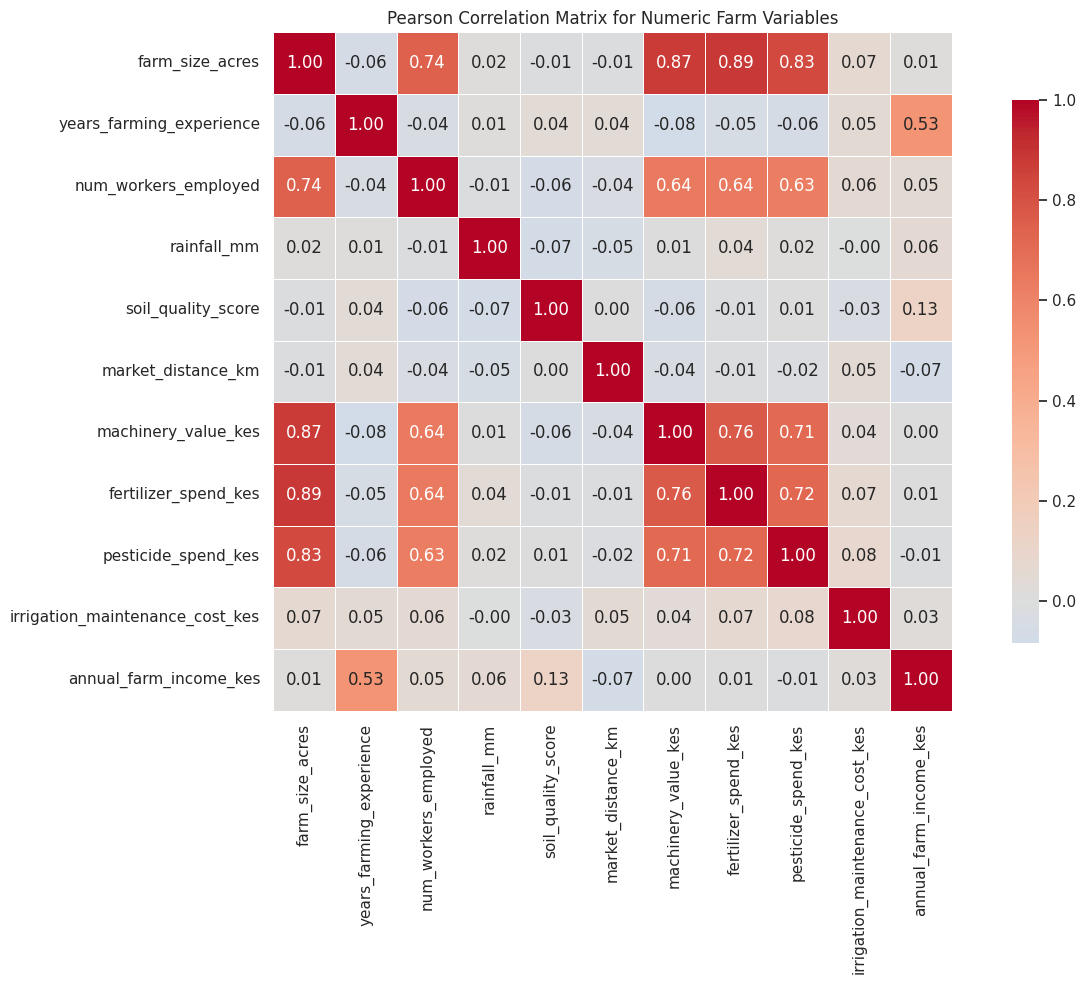

In [ ]:
heatmap_columns = [
    column for column in numeric_cols
    if column != "farm_id"
]

correlation_matrix = farm_data[heatmap_columns].corr(method="pearson")

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Pearson Correlation Matrix for Numeric Farm Variables")
plt.tight_layout()
plt.show()

## 4. Train/Test Split

The dataset is split into training data and test data before feature selection and preprocessing. This is important because fitting scalers, encoders, imputers, or feature-selection methods on the full dataset would allow information from the test data to influence the training process. This is known as data leakage and can produce overly optimistic model performance results.

In this analysis, 80% of the data will be used for training and 20% will be used for testing. Since annual farm income is strongly right-skewed, the target variable is divided into quantile-based groups before splitting. This helps to ensure that both the training and test datasets contain a similar mix of lower-, middle-, and higher-income farms.

In [ ]:
from sklearn.model_selection import train_test_split

# Income groups are created only to stratify the split.
# They are not used as model features.
income_bins = pd.qcut(
    farm_data[TARGET],
    q=5,
    labels=False,
    duplicates="drop"
)

# farm_id is an identifier, so it is excluded from model features.
feature_cols = [
    column for column in farm_data.columns
    if column not in ["farm_id", TARGET]
]

X = farm_data[feature_cols].copy()
y = farm_data[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=income_bins
)

print(f"Training data: {X_train.shape[0]} rows and {X_train.shape[1]} features")
print(f"Test data: {X_test.shape[0]} rows and {X_test.shape[1]} features")
print(f"Training income mean: {y_train.mean():,.2f} KES")
print(f"Test income mean: {y_test.mean():,.2f} KES")

Training data: 680 rows and 14 features
Test data: 170 rows and 14 features
Training income mean: 269,284.10 KES
Test income mean: 266,099.13 KES


The dataset was split into 680 training observations and 170 test observations. Both datasets contain 14 predictor variables. The `farm_id` column was excluded because it is an identifier, while `annual_farm_income_kes` was separated as the target variable.

The data was split using an 80:20 ratio. The training data will be used to select features, fit preprocessing steps, train models, and tune hyperparameters. The test data will remain untouched until the final evaluation stage.

Since annual farm income is strongly right-skewed, quantile-based income groups were used to stratify the split. This helps to ensure that both the training and test datasets contain a similar mix of lower-, middle-, and higher-income farms. The similar training and test income means also suggest that the split preserved the general income distribution.